## **Predicción Temprana del Riesgo Cardiovascular mediante Integración Inteligente de Datos Biométricos y de Hábitos Digitales**

*   Alumno: Alfredo Carreras Gómez
*   Director: Francisco Pascual Romero Chicharro
*   Codirector: José Antonio de la Torre las Herasho
---
*LIBRETA 3*

Esta libreta desarrolla una línea de trabajo avanzada basada en **Deep Learning** para complementar la fase de Modelado y Evaluación mediante **Autoencoders** para representación latente y segmentación de riesgo cardiovascular

Partimos del fichero `df_user_full_procesado.csv`, generado en la Libreta 1, donde cada fila representa un usuario y cada columna recoge información previamente depurada sobre variables biométricas,
hábitos de vida, indicadores de salud y engagement con la plataforma Wellat.

## Objetivos de esta libreta
1. Construir un pipeline reproducible de preprocesamiento.
2. Preparar una **matriz de entrada apta para redes neuronales**.
3. Entrenar un **Autoencoder** para aprender una representación latente compacta de los usuarios.
4. Evaluar la calidad de esa representación mediante:
   - error de reconstrucción,
   - curvas de entrenamiento/validación,
   - análisis del espacio latente,
   - clustering en el espacio latente.
5. Comparar varias configuraciones de número de clusters.
6. Interpretar los segmentos encontrados en términos de riesgo cardiovascular, engagement, utilidad clínica o empresarial.
7. Dejar preparada una base sólida para una segunda fase con:
   - clasificación supervisada,
   - modelos de similitud entre usuarios,
   - explicación de patrones,
   - aplicar ponderación diferencial a las variables clínicas para reforzar la separación por perfil de salud y no por nivel de engagement

## Hipótesis de trabajo: ¿por qué Autoencoders?
Un autoencoder puede aprender una representación más compacta y estructurada de los usuarios, capturando relaciones no lineales entre variables de salud, comportamiento y engagement. Esa representación latente puede ser especialmente útil para:
- mejorar la separación entre perfiles,
- detectar patrones complejos,
- y facilitar una segmentación más robusta que el uso directo del espacio original.

## 1. Configuración inicial del entorno

En esta sección:
- importamos librerías,
- fijamos semilla aleatoria,
- y preparamos utilidades para visualización y evaluación.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.model_selection import train_test_split

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
    from tensorflow.keras.models import Model
    from tensorflow.keras.regularizers import l2
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TF_AVAILABLE = True
except Exception as e:
    TF_AVAILABLE = False
    print("TensorFlow no está disponible:", e)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

if TF_AVAILABLE:
    tf.random.set_seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

print("TensorFlow disponible:", TF_AVAILABLE)
print("Semilla fijada en:", RANDOM_STATE)

TensorFlow disponible: True
Semilla fijada en: 42


## 2. Carga de datos

Cargamos y leemos el CSV df_user_full_procesado.csv y vamos a realizar unos cuantos ajustes:

Indexación: Vamos a establecer el userID como índice con el objetivo de evitar que actué como una característica y afecte en el cáclulo de distancias.

Codificación binaria: La variable gender la pasamos a un formato booleano para así facilitar su posterior procesamiento

Comprobamos el Shape del dataset: (4668 usuarios, 38 columnas)

In [ ]:
DATA_PATH = Path("df_user_full_procesado.csv")

df = pd.read_csv((DATA_PATH), sep=';', decimal=',', encoding='utf-8-sig')

if 'userID' in df.columns:
    df = df.set_index('userID')

if "gender" in df.columns:
    df['gender'] = df['gender'].map({'male': 1, 'female': 0})

print("Shape del dataset:", df.shape)
display(df.head())

Shape del dataset: (4668, 38)


,emotionalWorkshopEnrollments,mindfulnessTime,nutritionWorkshopEnrollments,physicalActivitySesions,age,allergies,avgExerciseIntensity,bmiType,bmi_clean,bodyFat,contentConsumptionMinutes,contentID,device,diet,dislikeRecipes,emotionalGoalsAchieved,fitnessAvailabilityDays,foodEnergyExpenditure,gamificationLevels,gamificationPoints,gender,height_clean,likeRecipes,nutritionalCategory,site,sleepGoal,stepsGoal,waistCirc,weight_clean,cardiovascularRecipeID,Has_Diabetes,Has_Colesterol,Has_Tension,Has_Hierro,Has_Calcio,Num_HealthProblems,Num_Allergies,Has_Mindfulness
userID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0,0.0,0,0,37,NaN,intense,overweight,27.78,2.0,52085.0,NaN,NaN,1.0,NaN,NaN,"MONDAY, TUESDAY, WEDNESDAY, THURSDAY",3163.22,1.0,0.0,1,1.79,NaN,NaN,1,480,10000,60.0,89.0,NaN,0,0,0,0,0,0,0,0
3,0,0.0,11,11,39,NaN,moderate,overweight,25.03,7.0,50788.0,"3,5,6,1,4",APPLE_WATCH,2.0,Tostada de pan de molde integral,0.0,"MONDAY, TUESDAY, WEDNESDAY, THURSDAY",2737.69,1.0,14355.0,1,1.81,Tosta de aguacate y tomate,NaN,1,480,10000,79.0,82.0,NaN,0,0,0,0,0,0,0,0
35,0,0.0,0,0,45,NaN,moderate,overweight,25.13,5.0,NaN,NaN,WELLAT_CAVOSMART,NaN,NaN,NaN,"MONDAY, TUESDAY, WEDNESDAY, FRIDAY, SATURDAY, ...",NaN,1.0,0.0,1,1.85,NaN,NaN,1,480,10000,97.0,86.0,NaN,0,0,0,0,0,0,0,0
50,0,23.0,0,2,45,NaN,moderate,normal_weight,24.09,6.0,50788.0,NaN,APPLE_WATCH,25.0,NaN,0.0,"MONDAY, WEDNESDAY, THURSDAY, SATURDAY",2019.26,1.0,7030.0,0,1.63,NaN,NaN,1,420,10000,60.0,64.0,NaN,0,0,0,0,0,0,0,0
92,0,112176.0,5,100,45,NaN,light,normal_weight,22.22,4.0,50788.0,"7,6,4,1",APPLE_WATCH,25.0,"Papas aliñadas, Tostada de queso manchego, Caf...",0.0,"MONDAY, WEDNESDAY, THURSDAY, SATURDAY",2234.38,2.0,100045.0,1,1.80,"Torta de arroz inflado integral, Plátano, Nara...",NaN,1,480,8500,87.0,72.0,NaN,0,0,0,0,0,0,0,1


## 3. Revisión rápida del dataset

Antes del modelado verificamos:
- tipos de variables,
- nulos,
- y posibles variables de texto libre que no conviene incluir en redes neuronales.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4668 entries, 1 to 12431
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   emotionalWorkshopEnrollments  4668 non-null   int64  
 1   mindfulnessTime               4668 non-null   float64
 2   nutritionWorkshopEnrollments  4668 non-null   int64  
 3   physicalActivitySesions       4668 non-null   int64  
 4   age                           4668 non-null   int64  
 5   allergies                     872 non-null    object 
 6   avgExerciseIntensity          4668 non-null   object 
 7   bmiType                       4668 non-null   object 
 8   bmi_clean                     4668 non-null   float64
 9   bodyFat                       4197 non-null   float64
 10  contentConsumptionMinutes     4294 non-null   float64
 11  contentID                     41 non-null     object 
 12  device                        2296 non-null   object 
 13  diet   

In [ ]:
nulls = df.isna().sum().sort_values(ascending=False)
display(nulls[nulls > 0].head(30))

,0
nutritionalCategory,4665
cardiovascularRecipeID,4665
contentID,4627
dislikeRecipes,4312
likeRecipes,4025
allergies,3796
device,2372
emotionalGoalsAchieved,1732
foodEnergyExpenditure,815
diet,815


In [ ]:
text_like_cols = []
for c in df.columns:
    if df[c].dtype == "object":
        avg_len = df[c].dropna().astype(str).str.len().mean() if df[c].notna().sum() > 0 else 0
        if avg_len and avg_len > 25:
            text_like_cols.append(c)

print("Posibles variables tipo texto libre:", text_like_cols)

Posibles variables tipo texto libre: ['dislikeRecipes', 'fitnessAvailabilityDays', 'likeRecipes', 'nutritionalCategory']


## 4. Exclusión de columnas problemáticas

Aquí definimos qué columnas queremos excluir del modelado.


In [ ]:
exclude_cols = [
    'dislikeRecipes',
    'fitnessAvailabilityDays',
    'likeRecipes',
    'nutritionalCategory',
    'cardiovascularRecipeID',
    'contentID']

## 5. Construcción de `df_model`

Creamos el dataset de modelado eliminando únicamente las variables excluidas.

Después revisaremos manualmente qué tipo de variable es cada columna.

In [ ]:
df_model = df.drop(columns=exclude_cols, errors="ignore").copy()
print("Shape de df_model:", df_model.shape)
display(df_model.head())

Shape de df_model: (4668, 32)


,emotionalWorkshopEnrollments,mindfulnessTime,nutritionWorkshopEnrollments,physicalActivitySesions,age,allergies,avgExerciseIntensity,bmiType,bmi_clean,bodyFat,contentConsumptionMinutes,device,diet,emotionalGoalsAchieved,foodEnergyExpenditure,gamificationLevels,gamificationPoints,gender,height_clean,site,sleepGoal,stepsGoal,waistCirc,weight_clean,Has_Diabetes,Has_Colesterol,Has_Tension,Has_Hierro,Has_Calcio,Num_HealthProblems,Num_Allergies,Has_Mindfulness
userID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0,0.0,0,0,37,NaN,intense,overweight,27.78,2.0,52085.0,NaN,1.0,NaN,3163.22,1.0,0.0,1,1.79,1,480,10000,60.0,89.0,0,0,0,0,0,0,0,0
3,0,0.0,11,11,39,NaN,moderate,overweight,25.03,7.0,50788.0,APPLE_WATCH,2.0,0.0,2737.69,1.0,14355.0,1,1.81,1,480,10000,79.0,82.0,0,0,0,0,0,0,0,0
35,0,0.0,0,0,45,NaN,moderate,overweight,25.13,5.0,NaN,WELLAT_CAVOSMART,NaN,NaN,NaN,1.0,0.0,1,1.85,1,480,10000,97.0,86.0,0,0,0,0,0,0,0,0
50,0,23.0,0,2,45,NaN,moderate,normal_weight,24.09,6.0,50788.0,APPLE_WATCH,25.0,0.0,2019.26,1.0,7030.0,0,1.63,1,420,10000,60.0,64.0,0,0,0,0,0,0,0,0
92,0,112176.0,5,100,45,NaN,light,normal_weight,22.22,4.0,50788.0,APPLE_WATCH,25.0,0.0,2234.38,2.0,100045.0,1,1.80,1,480,8500,87.0,72.0,0,0,0,0,0,0,0,1


## 6. Clasificación de variables por tipo

- **Continuas**: variables numéricas con magnitud y distancia significativa.
- **Binarias**: variables con dos estados (0/1, sí/no, presencia/ausencia).
- **Categóricas**: variables nominales u ordinales discretas que requieren tratamiento específico.


In [ ]:
# Detección inicial automática
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
object_cols = df_model.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

binary_cols = []
continuous_cols = []
categorical_cols = object_cols.copy()

for c in numeric_cols:
    unique_non_null = sorted(pd.Series(df_model[c].dropna().unique()).tolist())
    nunique = len(unique_non_null)
    if nunique == 2 and set(unique_non_null).issubset({0, 1}):
        binary_cols.append(c)
    else:
        continuous_cols.append(c)

print("Continuas detectadas:", len(continuous_cols))
print("Binarias detectadas:", len(binary_cols))
print("Categóricas detectadas:", len(categorical_cols))

Continuas detectadas: 21
Binarias detectadas: 7
Categóricas detectadas: 4


In [ ]:
print("Continuas:")
print(continuous_cols)

print("\nBinarias:")
print(binary_cols)

print("\nCategóricas:")
print(categorical_cols)

Continuas:
['emotionalWorkshopEnrollments', 'mindfulnessTime', 'nutritionWorkshopEnrollments', 'physicalActivitySesions', 'age', 'bmi_clean', 'bodyFat', 'contentConsumptionMinutes', 'diet', 'emotionalGoalsAchieved', 'foodEnergyExpenditure', 'gamificationLevels', 'gamificationPoints', 'height_clean', 'site', 'sleepGoal', 'stepsGoal', 'waistCirc', 'weight_clean', 'Num_HealthProblems', 'Num_Allergies']

Binarias:
['gender', 'Has_Diabetes', 'Has_Colesterol', 'Has_Tension', 'Has_Hierro', 'Has_Calcio', 'Has_Mindfulness']

Categóricas:
['allergies', 'avgExerciseIntensity', 'bmiType', 'device']


### Numéricas ordinales escaladas

Se observa que la variable ordinal  `gamificationLevels` se identifica como numérica y no categórica, es correcto ya que voy a tratarla como numéricas ordinales escalada ya que representa progresión real de engagement.

## 7. Pipeline de preprocesamiento

Transformamos todas las variables en una matriz numérica lista para Deep Learning:

- continuas (BMI, pasos, kcal, sueño...) → imputación KNN + escalado,
- binarias → imputación por moda,
- categóricas → imputación por moda + one-hot encoding.

Se emplea imputación mediante KNN en variables continuas para preservar la estructura multivariable de los datos, permitiendo estimar valores faltantes en función de la similitud entre individuos. El posterior escalado es necesario para evitar que variables con mayor rango dominen el cálculo de distancias.

En variables binarias (como has_diabetes o has_mindfluness)se emplea imputación por moda, ya que este tipo de variables no presenta una estructura continua que permita aplicar métodos basados en distancia, siendo la moda la estrategia más robusta para preservar la distribución original.

Las variables categóricas se imputan mediante la moda al no existir una relación de orden entre sus valores. Posteriormente, se aplica codificación one-hot para transformar dichas variables en representaciones numéricas sin introducir relaciones artificiales de jerarquía.

El resultado será una matriz `X` adecuada para entrenar el autoencoder.

In [ ]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

binary_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, continuous_cols),
        ("bin", binary_pipeline, binary_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ],
    remainder="drop"
)

print("Pipeline de preprocesamiento definido correctamente.")
print(f"Continuas: {len(continuous_cols)} | Binarias: {len(binary_cols)} | Categóricas: {len(categorical_cols)}")

Pipeline de preprocesamiento definido correctamente.
Continuas: 21 | Binarias: 7 | Categóricas: 4


In [ ]:
print("Columnas continuas:", continuous_cols[:15], "..." if len(continuous_cols) > 15 else "")
print("Columnas binarias:", binary_cols[:15], "..." if len(binary_cols) > 15 else "")
print("Columnas categóricas:", categorical_cols[:15], "..." if len(categorical_cols) > 15 else "")

print("\nTotal de columnas originales en df_model:", df_model.shape[1])

Columnas continuas: ['emotionalWorkshopEnrollments', 'mindfulnessTime', 'nutritionWorkshopEnrollments', 'physicalActivitySesions', 'age', 'bmi_clean', 'bodyFat', 'contentConsumptionMinutes', 'diet', 'emotionalGoalsAchieved', 'foodEnergyExpenditure', 'gamificationLevels', 'gamificationPoints', 'height_clean', 'site'] ...
Columnas binarias: ['gender', 'Has_Diabetes', 'Has_Colesterol', 'Has_Tension', 'Has_Hierro', 'Has_Calcio', 'Has_Mindfulness'] 
Columnas categóricas: ['allergies', 'avgExerciseIntensity', 'bmiType', 'device'] 

Total de columnas originales en df_model: 32


## 8. División train/validation

Aunque el autoencoder es no supervisado, conviene reservar una parte de los datos para validar:
- capacidad de reconstrucción,
- sobreajuste,
- estabilidad del entrenamiento.

In [ ]:
X_train_df, X_val_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Ajuste SOLO con train para evitar data leakage
X_train = preprocessor.fit_transform(X_train_df)
X_val = preprocessor.transform(X_val_df)

# Transformación del dataset completo con el preprocesador ya ajustado
X_all = preprocessor.transform(df_model)

feature_names = preprocessor.get_feature_names_out()

df_train_transformed = pd.DataFrame(
    X_train,
    columns=feature_names,
    index=X_train_df.index
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_all:", X_all.shape)
print("NaNs en X_train:", np.isnan(X_train).sum())
print("NaNs en X_val:", np.isnan(X_val).sum())

display(df_train_transformed.head())

X_train: (3734, 377)
X_val: (934, 377)
X_all: (4668, 377)
NaNs en X_train: 0
NaNs en X_val: 0


,num__emotionalWorkshopEnrollments,num__mindfulnessTime,num__nutritionWorkshopEnrollments,num__physicalActivitySesions,num__age,num__bmi_clean,num__bodyFat,num__contentConsumptionMinutes,num__diet,num__emotionalGoalsAchieved,num__foodEnergyExpenditure,num__gamificationLevels,num__gamificationPoints,num__height_clean,num__site,num__sleepGoal,num__stepsGoal,num__waistCirc,num__weight_clean,num__Num_HealthProblems,num__Num_Allergies,bin__gender,bin__Has_Diabetes,bin__Has_Colesterol,bin__Has_Tension,bin__Has_Hierro,bin__Has_Calcio,bin__Has_Mindfulness,cat__allergies_1,"cat__allergies_1, 1","cat__allergies_1, 10, 13, 14","cat__allergies_1, 2","cat__allergies_1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13","cat__allergies_1, 2, 3, 4, 5, 6, 8, 9, 11, 12","cat__allergies_1, 2, 3, 4, 5, 7, 8, 10, 11, 12","cat__allergies_1, 2, 3, 4, 6, 7, 8, 9, 12, 13","cat__allergies_1, 2, 3, 4, 7","cat__allergies_1, 2, 3, 4, 7, 9, 11","cat__allergies_1, 2, 3, 4, 7, 9, 12","cat__allergies_1, 2, 3, 5, 7, 8","cat__allergies_1, 2, 4, 12, 13, 14","cat__allergies_1, 3","cat__allergies_1, 3, 2, 4, 5, 7, 8, 10, 12, 13, 14","cat__allergies_1, 3, 4","cat__allergies_1, 3, 4, 5, 12","cat__allergies_1, 3, 4, 5, 6, 2, 8, 7, 9, 12","cat__allergies_1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13","cat__allergies_1, 3, 4, 6, 7, 14","cat__allergies_1, 3, 4, 6, 7, 5, 8, 10, 9, 12, 13, 11","cat__allergies_1, 3, 4, 7","cat__allergies_1, 3, 4, 7, 2, 6, 9, 10, 12, 13, 14","cat__allergies_1, 3, 4, 7, 8","cat__allergies_1, 3, 5, 11, 4","cat__allergies_1, 3, 5, 7","cat__allergies_1, 3, 5, 7, 8","cat__allergies_1, 3, 7","cat__allergies_1, 3, 7, 8, 10, 11, 13, 14","cat__allergies_1, 4","cat__allergies_1, 4, 3, 6, 11","cat__allergies_1, 4, 3, 8, 7, 10, 11, 2","cat__allergies_1, 5, 3, 7","cat__allergies_1, 5, 6","cat__allergies_1, 5, 6, 7, 10, 13, 14","cat__allergies_1, 5, 6, 7, 14","cat__allergies_1, 5, 6, 8, 11","cat__allergies_1, 6","cat__allergies_1, 6, 5, 7","cat__allergies_1, 7","cat__allergies_1, 7, 1, 7","cat__allergies_1, 7, 11","cat__allergies_1, 7, 12","cat__allergies_1, 7, 12, 2, 4, 13","cat__allergies_1, 7, 14","cat__allergies_1, 7, 5, 14","cat__allergies_1, 8",cat__allergies_1.0,cat__allergies_10,"cat__allergies_10, 10","cat__allergies_10, 11","cat__allergies_10, 14","cat__allergies_10, 9, 12","cat__allergies_10, 9, 8, 5",cat__allergies_12,"cat__allergies_12, 12","cat__allergies_12, 13, 2","cat__allergies_12, 13, 8, 6, 7, 4, 3, 2","cat__allergies_12, 2","cat__allergies_12, 2, 10",cat__allergies_13,"cat__allergies_13, 10",cat__allergies_14,"cat__allergies_14, 14","cat__allergies_14, 9, 1",cat__allergies_2,"cat__allergies_2, 12","cat__allergies_2, 12, 13","cat__allergies_2, 12, 13, 14","cat__allergies_2, 12, 2, 12","cat__allergies_2, 12, 9","cat__allergies_2, 13",...,cat__allergies_4,"cat__allergies_4, 10","cat__allergies_4, 12","cat__allergies_4, 2","cat__allergies_4, 2, 1, 3, 5, 7, 12","cat__allergies_4, 2, 12","cat__allergies_4, 2, 3, 7","cat__allergies_4, 2, 3, 9, 12, 5, 8","cat__allergies_4, 2, 5, 12, 11, 13","cat__allergies_4, 2, 6","cat__allergies_4, 2, 7, 12","cat__allergies_4, 3","cat__allergies_4, 3, 2, 12","cat__allergies_4, 3, 5, 6","cat__allergies_4, 3, 5, 7","cat__allergies_4, 3, 5, 7, 12, 13","cat__allergies_4, 3, 7","cat__allergies_4, 3, 7, 9, 12","cat__allergies_4, 4","cat__allergies_4, 5, 3, 1, 7, 6, 8, 12","cat__allergies_4, 5, 6, 7, 9, 11, 12","cat__allergies_4, 5, 7","cat__allergies_4, 6, 2, 12, 8, 3","cat__allergies_4, 7","cat__allergies_4, 7, 8","cat__allergies_4, 8, 6","cat__allergies_4, 8, 7, 3","cat__allergies_4, 9",cat__allergies_5,"cat__allergies_5, 1, 10","cat__allergies_5, 1, 4, 12, 13, 8, 6, 2, 7, 10, 9, 14, 11","cat__allergies_5, 10","cat__allergies_5, 3, 4, 7, 11","cat__allergies_5, 4, 7, 10, 12, 3","cat__allergies_5, 5","cat__allergies_5, 5, 8","cat__allergies_5, 6, 14","cat__allergies_5, 6, 7, 8","cat__allergies_5, 6, 8, 9, 10, 11, 13","cat__allergies_5, 8","cat__allergies_5, 8, 10","cat__allergies_5, 8, 11","cat__allergies_5, 8, 13","cat__allergies_5, 9,

## Normalización

La normalización se realiza **dentro del pipeline de preprocesamiento**, concretamente sobre las variables continuas mediante `StandardScaler`.

De este modo:
- evitamos escalados duplicados,
- mantenemos un flujo limpio y reproducible,
- y prevenimos *data leakage*, ya que el preprocesador se ajusta solo con `X_train_df`.


In [ ]:
print("Media global aproximada de X_train:", np.mean(X_train))
print("Desviación típica global aproximada de X_train:", np.std(X_train))
print("Número total de features tras el preprocesado:", X_train.shape[1])

Media global aproximada de X_train: 0.012517421813175646
Desviación típica global aproximada de X_train: 0.26089011812678914
Número total de features tras el preprocesado: 377


Tras el preprocesamiento, se obtiene una matriz de entrada compuesta por variables continuas escaladas mediante StandardScaler y variables binarias y categóricas transformadas mediante codificación one-hot.

La media global del conjunto de entrenamiento se sitúa próxima a cero, mientras que la desviación típica global es inferior a la unidad. Este comportamiento es esperable, ya que únicamente las variables continuas han sido estandarizadas, mientras que las variables binarias y categóricas mantienen su escala original en el rango [0,1].

Esta combinación de variables genera una distribución heterogénea en el espacio de entrada, lo que se considera adecuado para preservar la semántica de cada tipo de dato, aunque puede influir en la forma en que el modelo pondera los distintos tipos de variables durante el entrenamiento.

Después del preprocesamiento obtenemos **377 columnas/features**.

## 9. Definición del Autoencoder

### Arquitectura base
Usaremos un autoencoder denso:
- entrada -> capas ocultas -> cuello de botella (espacio latente) -> reconstrucción.



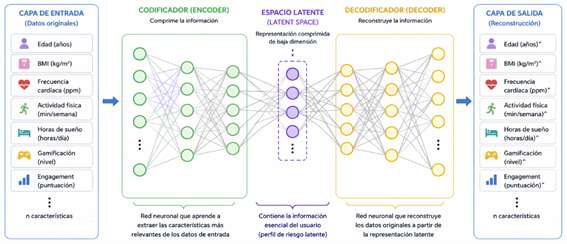

La dimensión latente es un hiperparámetro importante:
- demasiado pequeña: pierde información,
- demasiado grande: apenas comprime y puede aprender una identidad trivial.

## PRIMERA ITERACIÓN
Empezaremos con una dimensión latente moderada y luego podremos iterar.

* Pasamos a 8 dimensiones (`377 → 64 → 32 → 8 → 32 → 64 → 377`).
* Esta compresión es agresiva, por lo que habrá que validar si el espacio latente conserva suficiente información para reconstrucción y clustering.


Utilizaré `BatchNormalization` para que el entrenamiento sea más estable, el modelo aprenda más rápido y se reduzcan oscilaciones internas.

También usaré `Dropout(0.3)` durante el entrenamiento para apagar aleatoriamente un 30% de neuronas y así obligar al modelo a no depender demasiado de unas pocas neuronas y mejorar la generalización.

Y por último utilizaré `kernel_regularizer=l2(1e-3)` para penalizar pesos demasiado grandes y evitar que la red memorice demasiado el conjunto de entrenamiento.

In [ ]:
input_dim = X_train.shape[1]
latent_dim = 8

input_layer = Input(shape=(input_dim,), name="input_layer")

# Encoder (377 → 64 → 32 → 8)
x = Dense(
    64,
    activation="relu",
    kernel_regularizer=l2(1e-3)
)(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(
    32,
    activation="relu",
    kernel_regularizer=l2(1e-3)
)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

latent = Dense(
    latent_dim,
    activation="linear",
    name="latent_space"
)(x)

# Decoder (8 → 32 → 64 → 377)
x = Dense(
    32,
    activation="relu",
    kernel_regularizer=l2(1e-3)
)(latent)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(
    64,
    activation="relu",
    kernel_regularizer=l2(1e-3)
)(x)
x = BatchNormalization()(x)

output_layer = Dense(
    input_dim,
    activation="linear",
    name="reconstruction"
)(x)

# Modelos
autoencoder = Model(inputs=input_layer, outputs=output_layer, name="autoencoder")
encoder = Model(inputs=input_layer, outputs=latent, name="encoder")

# Resumen
print("Dimensión de entrada:", input_dim)
print("Dimensión latente:", latent_dim)
autoencoder.summary()

Dimensión de entrada: 377
Dimensión latente: 8


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 377)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        24,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 377)            │        24,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,209 (211.75 KB)

 Trainable params: 53,825 (210.25 KB)

 Non-trainable params: 384 (1.50 KB)

El modelo tiene unos 54.209 parámetros internos. Son los pesos que aprende durante el entrenamiento.
Nº de parámetros por capa:
*   1ª capa: 24,192 parámetros (377 entradas - 64 neuronas + 64 sesgos)
*   Latent_space: 32 × 8 + 8 = 264




A continuación defino cómo va a aprender el modelo, cómo se evalúa y cómo reaccion si deja de mejorar.


*   Cómo aprende: `Adam`. Calcula cómo cambiar los pesos para reducir el error. Usa información histórica (momentum). Es robusto y rápido.
*   Minimizar el error `mse`. Queremos reconstruir los 377 valores originales
minimizando el error cuadrático
*   Evaluo con `MAE` ( |valor_real - valor_reconstruido| ) porque es más robusto que MSE, más interpretable y menos sensible a outliers.
*   EarlyStopping. Vigila la pérdida de validación y si durante 5 épocas val_loss NO mejora, para el entrenamiento



In [ ]:
# Compilación
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-5
    )
]

print("Modelo compilado correctamente.")
print("Loss:", autoencoder.loss)
print("Métricas:", autoencoder.metrics_names)

Modelo compilado correctamente.
Loss: mse
Métricas: ['loss', 'compile_metrics']


Configuración del entrenamiento:

*   **epochs = 150**: El modelo puede entrenar hasta 150 pasadas completas sobre el conjunto de entrenamiento. Con EarlyStopping probablemente se detendrá antes.

*   **batch_size = 3**2. El modelo actualiza sus pesos cada 32 registros. Es un tamaño razonable para datos tabulares.

*   **shuffle = True**. Mezcla los registros antes de cada época. Evita que el modelo aprenda patrones derivados del orden de los datos.

*   **optimizer = Adam(learning_rate=1e-3)**. Usaré Adam con tasa de aprendizaje inicial 0.001.

*   **loss = mse**. El modelo minimiza el error cuadrático medio de reconstrucción.

*   **metrics = [mae]**. Además del MSE, monitorizo el error absoluto medio.

In [ ]:
training_config = {
    "epochs": 150,
    "batch_size": 32,
    "shuffle": True,
    "optimizer": "Adam(learning_rate=1e-3)",
    "loss": "mse",
    "metrics": ["mae"],
    "latent_dim": latent_dim
}

pd.DataFrame([training_config])

,epochs,batch_size,shuffle,optimizer,loss,metrics,latent_dim
0,150,32,True,Adam(learning_rate=1e-3),mse,[mae],8


In [ ]:
print("Parámetros entrenables del autoencoder:", autoencoder.count_params())
print("Dimensión de entrada:", input_dim)
print("Dimensión latente:", latent_dim)

Parámetros entrenables del autoencoder: 54209
Dimensión de entrada: 377
Dimensión latente: 8


## 10. Entrenamiento del modelo

Entrenamos el autoencoder para que aprenda a reconstruir su entrada. Vigilamos:
- pérdida de entrenamiento,
- pérdida de validación,
- diferencia entre ambas.

Si la validación empeora mientras entrenamiento mejora, puede haber sobreajuste.

In [ ]:
history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=150,
    batch_size=32,
    shuffle=True,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.2502 - mae: 0.1966 - val_loss: 0.2109 - val_mae: 0.0566 - learning_rate: 0.0010
Epoch 2/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1278 - mae: 0.0875 - val_loss: 0.1725 - val_mae: 0.0510 - learning_rate: 0.0010
Epoch 3/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0953 - mae: 0.0675 - val_loss: 0.1466 - val_mae: 0.0481 - learning_rate: 0.0010
Epoch 4/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0758 - mae: 0.0595 - val_loss: 0.1323 - val_mae: 0.0474 - learning_rate: 0.0010
Epoch 5/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0636 - mae: 0.0560 - val_loss: 0.1241 - val_mae: 0.0465 - learning_rate: 0.0010
Epoch 6/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0558 - mae: 0.0549 - val_loss: 0.1162 - val_mae: 0.0474 - learning_rate: 0.0010
Epoch 7/150
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0515 - mae: 0.0531 - val_loss: 0.1118 - val_mae: 0.0481 - learning_rate: 0.0010

El modelo aprende rápido. Captura estructura en pocas épocas.
*   val_loss mínimo ≈ 0.1046 (epoch 12) siendo el mejor punto real
*   A partir de epoch 12–17, val_loss sube → 0.1599 → 0.122 → 0.114: Overfitting + inestabilidad. El modelo sigue mejorando en train pero validation oscila incluso empeora fuerte (epoch 14)
*   Al comparar MSE (oscila mucho) y MAE (es estable) podria traducirse como que hay outliers o casos raros, y podria identificar usuarios con posibles riesgos.

## SEGUNDA ITERACIÓN
Vamos a realizar los siguientes ajustes:

*   Reducir epochs a 100
*   Ajustar early stopping a 5
*   Probar más regularización. Dropout(0.35), l2(1e-3)
*   Probar más dimensiones latentes: [16]

In [ ]:
latent_dim = 16

# Encoder
x = Dense(64, activation="relu", kernel_regularizer=l2(1e-3))(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.35)(x)

x = Dense(32, activation="relu", kernel_regularizer=l2(1e-3))(x)
x = BatchNormalization()(x)
x = Dropout(0.35)(x)

latent = Dense(latent_dim, activation="linear", name="latent_space")(x)

# Decoder
x = Dense(32, activation="relu", kernel_regularizer=l2(1e-3))(latent)
x = BatchNormalization()(x)
x = Dropout(0.35)(x)

x = Dense(64, activation="relu", kernel_regularizer=l2(1e-3))(x)
x = BatchNormalization()(x)

output_layer = Dense(input_dim, activation="linear", name="reconstruction")(x)

# Compilación
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
]

history = autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=32,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.2654 - mae: 0.2121 - val_loss: 0.2144 - val_mae: 0.0564 - learning_rate: 0.0010
Epoch 2/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1314 - mae: 0.0905 - val_loss: 0.1721 - val_mae: 0.0509 - learning_rate: 0.0010
Epoch 3/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0966 - mae: 0.0683 - val_loss: 0.1453 - val_mae: 0.0484 - learning_rate: 0.0010
Epoch 4/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0759 - mae: 0.0605 - val_loss: 0.1297 - val_mae: 0.0468 - learning_rate: 0.0010
Epoch 5/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0629 - mae: 0.0572 - val_loss: 0.1202 - val_mae: 0.0467 - learning_rate: 0.0010
Epoch 6/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0547 - mae: 0.0549 - val_loss: 0.1120 - val_mae: 0.0441 - learning_rate: 0.0010
Epoch 7/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0494 - mae: 0.0531 - val_loss: 0.1036 - val_mae: 0.0450 - learning_rate: 0.0

Esta configuración ha mejorado respecto a la anterior.
Mejor epoch: 9, val_loss: 0.0920, val_mae: 0.0437

El modelo con latent_dim = 16 reconstruye mejor que el de 8. 8 dimensiones eran probablemente demasiado restrictivas para resumir las 377 variables del dataset.

La red aprende rápido hasta la época 9. Después, aunque el entrenamiento sigue mejorando, la validación empeora u oscila. Hay sobreajuste moderado, pero está bien controlado gracias a EarlyStopping.



## 11. Curvas de entrenamiento

Estas gráficas permiten evaluar la calidad del aprendizaje.

### Interpretación esperada
- ambas curvas bajan → aprendizaje estable,
- val_loss cercana a loss → buena generalización,
- separación excesiva → posible sobreajuste.

In [ ]:
history_df = pd.DataFrame(history.history)
display(history_df.head())

,loss,mae,val_loss,val_mae,learning_rate
0,0.250196,0.196633,0.210948,0.056607,0.001
1,0.127766,0.087454,0.172497,0.051031,0.001
2,0.095321,0.067459,0.146609,0.048063,0.001
3,0.075816,0.059539,0.132350,0.047447,0.001
4,0.063572,0.055977,0.124081,0.046514,0.001


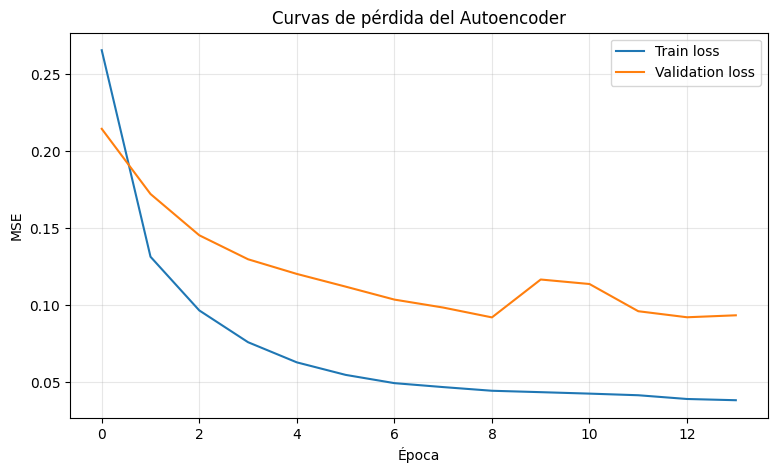

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Curvas de pérdida del Autoencoder")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Las curvas de entrenamiento muestran una reducción progresiva del error tanto en entrenamiento como en validación, lo que indica que el modelo es capaz de aprender una representación significativa de los datos.

El mínimo de la función de pérdida en validación se alcanza en torno a la época 9, a partir de la cual se observa un ligero incremento del error, evidenciando la aparición de sobreajuste.

No obstante, la diferencia entre las curvas de entrenamiento y validación es moderada, lo que sugiere una capacidad de generalización razonable.

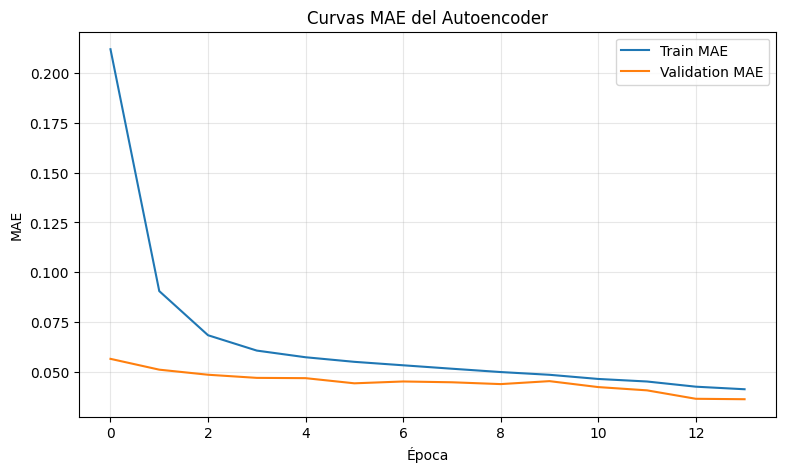

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.title("Curvas MAE del Autoencoder")
plt.xlabel("Época")
plt.ylabel("MAE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

El error absoluto medio muestra una evolución estable y convergente tanto en entrenamiento como en validación, lo que indica que el modelo es capaz de reconstruir adecuadamente la mayoría de las observaciones.

La cercanía entre ambas curvas sugiere una **buena capacidad de generalización** en términos de error medio.

## 12. Error de reconstrucción

El error de reconstrucción mide cuánto se desvía la salida reconstruida respecto a la entrada.

### Para qué sirve
- evaluar calidad del autoencoder,
- detectar usuarios atípicos,
- identificar perfiles difíciles de reconstruir.

En algunos escenarios, un error alto puede sugerir perfiles anómalos o inusuales.

In [ ]:
X_train_recon = autoencoder.predict(X_train, verbose=0)
X_val_recon = autoencoder.predict(X_val, verbose=0)

train_reconstruction_error = np.mean(np.square(X_train - X_train_recon), axis=1)
val_reconstruction_error = np.mean(np.square(X_val - X_val_recon), axis=1)

print("Error medio reconstrucción train:", train_reconstruction_error.mean())
print("Error medio reconstrucción val:", val_reconstruction_error.mean())

Error medio reconstrucción train: 0.038164488430822485
Error medio reconstrucción val: 0.100989371093065


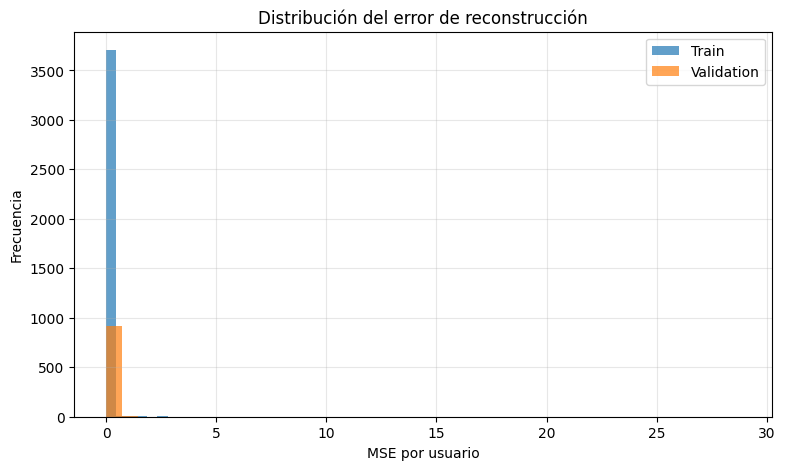

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(train_reconstruction_error, bins=40, alpha=0.7, label="Train")
plt.hist(val_reconstruction_error, bins=40, alpha=0.7, label="Validation")
plt.title("Distribución del error de reconstrucción")
plt.xlabel("MSE por usuario")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
threshold_anomaly = np.percentile(val_reconstruction_error, 95)
print("Umbral orientativo percentil 95:", threshold_anomaly)

n_anomalous = (val_reconstruction_error >= threshold_anomaly).sum()
print("Usuarios de validación por encima del umbral:", n_anomalous)

Umbral orientativo percentil 95: 0.05794118559907553
Usuarios de validación por encima del umbral: 47


El 95% de usuarios “normales” (train) tienen error < 0.058. El 5% restante considerados “anómalos”
47 usuarios por encima del umbral

## 13. Obtención del espacio latente

Ahora proyectamos todos los usuarios al espacio latente aprendido por el encoder.

Este espacio es la representación comprimida que utilizaremos para:
- visualizar estructura,
- aplicar clustering,
- interpretar segmentos.

In [ ]:
Z = encoder.predict(X_all, verbose=0)
df_latent = pd.DataFrame(
    Z,
    columns=[f"latent_{i+1}" for i in range(Z.shape[1])],
    index=df_model.index
)

print("Shape del espacio latente:", df_latent.shape)
display(df_latent.head())

Shape del espacio latente: (4668, 16)


,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,latent_16
userID,,,,,,,,,,,,,,,,
1,-0.518990,1.617221,-1.606301,1.715395,0.323254,0.605858,-1.567691,0.122961,-0.079093,1.158285,1.323231,-0.999769,0.519216,0.828193,-1.499725,-0.661010
3,2.964424,-3.941912,-5.378793,5.832203,-5.974557,-1.304265,-0.511607,-11.035043,5.073099,4.871497,-2.549934,-3.123851,17.262548,-5.847088,6.799026,4.793224
35,5.361547,1.789875,3.664107,1.640056,0.753023,0.803612,-1.278652,1.223806,0.256219,-0.398665,0.211386,-4.729771,-1.348023,0.261258,4.577825,-1.142788
50,-1.862558,-0.568426,-0.092175,-0.195988,1.184784,1.039778,2.357018,0.760092,-1.534233,0.517550,-0.944068,-1.185615,-0.872487,-0.401113,0.035466,2.228712
92,7.008207,-17.539579,-16.628569,14.836812,3.287387,4.878048,15.878282,1.692481,-35.459129,-0.424891,-1.248089,18.747187,20.647709,-15.070043,6.625628,29.197145


Los 4668 usuarios cada uno representado por 16 variables latentes
Estas variables NO son interpretables directamente (Cada dimensión es una combinación no lineal de muchas variables)

Se detectan valores muy grandes como:

*   latent_9 = -35
*   latent_16 = +29

El espacio latente no está regularizado. Escalas muy diferentes entre dimensiones.

Tomo decisión de normalizar el espacio latente antes de clustering

In [ ]:
scaler_latent = StandardScaler()
Z_scaled = scaler_latent.fit_transform(Z)

## 14. Visualización 2D del espacio latente

Aunque el espacio latente puede tener más de 2 dimensiones, proyectarlo en 2 componentes facilita la inspección visual.

Varianza explicada por PC1 y PC2: [0.24064068 0.21225838]
Varianza acumulada: 0.45289907


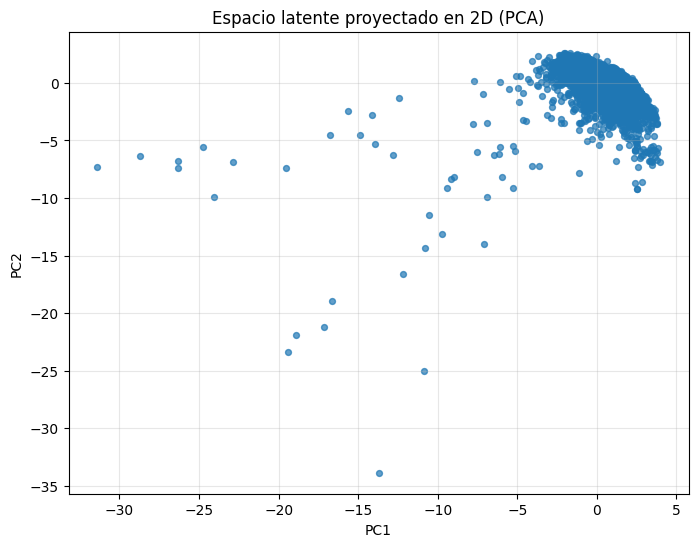

In [ ]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
Z_pca = pca_2d.fit_transform(Z_scaled)

explained_var = pca_2d.explained_variance_ratio_
print("Varianza explicada por PC1 y PC2:", explained_var)
print("Varianza acumulada:", explained_var.sum())

plt.figure(figsize=(8, 6))
plt.scatter(Z_pca[:, 0], Z_pca[:, 1], s=18, alpha=0.7)
plt.title("Espacio latente proyectado en 2D (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

Se ve un núcleo denso con usuarios normales o mayoritarios, mientras usuarios atípicos dispersos

## 15. Clustering sobre el espacio latente

La idea central es que el autoencoder haya aprendido una representación más informativa y compacta.  
Ahora evaluamos si esa representación facilita la separación entre grupos.

Empezaremos con K-Means y Agglomerative.

In [ ]:
results = []

for k in range(2, 7):
    # K-Means
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_labels = km.fit_predict(Z)

    results.append({
        "model": "KMeans",
        "k": k,
        "silhouette": silhouette_score(Z, km_labels),
        "davies_bouldin": davies_bouldin_score(Z, km_labels),
        "calinski_harabasz": calinski_harabasz_score(Z, km_labels)
    })

    # Agglomerative
    agg = AgglomerativeClustering(n_clusters=k)
    agg_labels = agg.fit_predict(Z)

    results.append({
        "model": "Agglomerative",
        "k": k,
        "silhouette": silhouette_score(Z, agg_labels),
        "davies_bouldin": davies_bouldin_score(Z, agg_labels),
        "calinski_harabasz": calinski_harabasz_score(Z, agg_labels)
    })

results_df = pd.DataFrame(results).sort_values(
    by=["silhouette", "davies_bouldin"],
    ascending=[False, True]
)

display(results_df)

,model,k,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,2,0.828186,0.970974,1007.248535
1,Agglomerative,2,0.799178,1.062953,793.388977
6,KMeans,5,0.266433,1.133617,1109.491211
4,KMeans,4,0.248285,1.156920,1145.141724
2,KMeans,3,0.246018,1.341958,1230.240601
5,Agglomerative,4,0.242732,1.113263,841.020081
7,Agglomerative,5,0.241340,1.101258,831.300476
3,Agglomerative,3,0.240775,1.407084,852.400879
8,KMeans,6,0.177103,1.359665,1061.862427
9,Agglomerative,6,0.131205,1.460456,816.951660


KMeans (k=2) → silhouette = 0.828 es altísimo. Separacion extremedamente clara: detección de dos tipos de usuarios (normales vs anómalos)

## 16. Selección preliminar del mejor modelo de clustering

### Criterios
- **Silhouette**: más alto es mejor.
- **Davies-Bouldin**: más bajo es mejor.
- **Calinski-Harabasz**: más alto es mejor.

Además de las métricas, recuerda considerar:
- interpretabilidad,
- tamaño de clusters,
- utilidad clínica,
- accionabilidad empresarial.

In [ ]:
best_row = results_df.iloc[0]
best_model_name = best_row["model"]
best_k = int(best_row["k"])

print("Mejor combinación preliminar:")
display(best_row)

Mejor combinación preliminar:


,0
model,KMeans
k,2
silhouette,0.828186
davies_bouldin,0.970974
calinski_harabasz,1007.248535


In [ ]:
if best_model_name == "KMeans":
    best_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
else:
    best_model = AgglomerativeClustering(n_clusters=best_k)

cluster_labels = best_model.fit_predict(Z)

df_analysis = df_model.copy()
df_analysis["cluster"] = cluster_labels

print(df_analysis["cluster"].value_counts().sort_index())
display(df_analysis.head())

cluster
0    4637
1      31
Name: count, dtype: int64


,emotionalWorkshopEnrollments,mindfulnessTime,nutritionWorkshopEnrollments,physicalActivitySesions,age,allergies,avgExerciseIntensity,bmiType,bmi_clean,bodyFat,contentConsumptionMinutes,device,diet,emotionalGoalsAchieved,foodEnergyExpenditure,gamificationLevels,gamificationPoints,gender,height_clean,site,sleepGoal,stepsGoal,waistCirc,weight_clean,Has_Diabetes,Has_Colesterol,Has_Tension,Has_Hierro,Has_Calcio,Num_HealthProblems,Num_Allergies,Has_Mindfulness,cluster
userID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0,0.0,0,0,37,NaN,intense,overweight,27.78,2.0,52085.0,NaN,1.0,NaN,3163.22,1.0,0.0,1,1.79,1,480,10000,60.0,89.0,0,0,0,0,0,0,0,0,0
3,0,0.0,11,11,39,NaN,moderate,overweight,25.03,7.0,50788.0,APPLE_WATCH,2.0,0.0,2737.69,1.0,14355.0,1,1.81,1,480,10000,79.0,82.0,0,0,0,0,0,0,0,0,1
35,0,0.0,0,0,45,NaN,moderate,overweight,25.13,5.0,NaN,WELLAT_CAVOSMART,NaN,NaN,NaN,1.0,0.0,1,1.85,1,480,10000,97.0,86.0,0,0,0,0,0,0,0,0,0
50,0,23.0,0,2,45,NaN,moderate,normal_weight,24.09,6.0,50788.0,APPLE_WATCH,25.0,0.0,2019.26,1.0,7030.0,0,1.63,1,420,10000,60.0,64.0,0,0,0,0,0,0,0,0,0
92,0,112176.0,5,100,45,NaN,light,normal_weight,22.22,4.0,50788.0,APPLE_WATCH,25.0,0.0,2234.38,2.0,100045.0,1,1.80,1,480,8500,87.0,72.0,0,0,0,0,0,0,0,1,1


## 17. Visualización de clusters en 2D

Representamos los clusters sobre la proyección PCA del espacio latente.

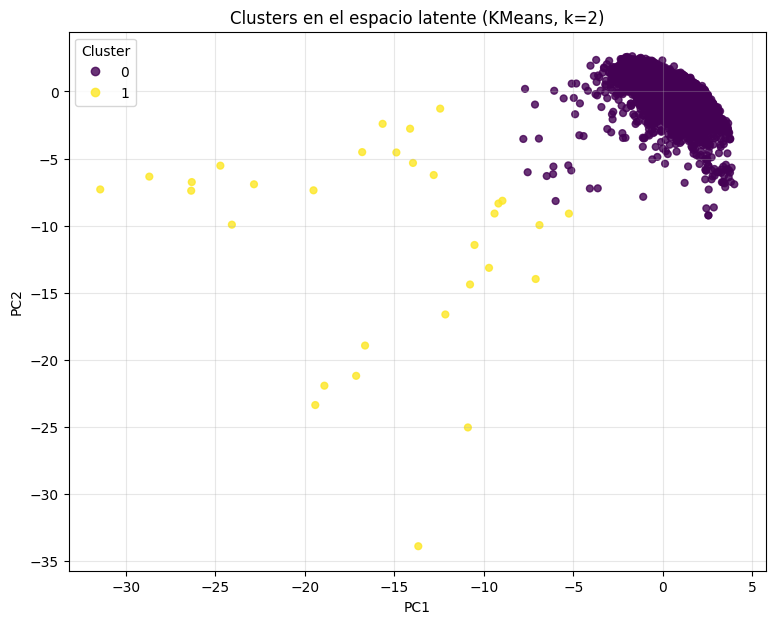

In [ ]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    Z_pca[:, 0],
    Z_pca[:, 1],
    c=cluster_labels,
    s=24,
    alpha=0.8
)
plt.title(f"Clusters en el espacio latente ({best_model_name}, k={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

## 18. Perfilado de clusters

Aquí calculamos estadísticas descriptivas para interpretar cada grupo.

### Qué buscamos
- clusters con mayor edad,
- mayor BMI,
- peores hábitos,
- menor engagement,
- o combinaciones mixtas de riesgo y comportamiento.

Estas tablas serán la base para asignar significado a los grupos.

In [ ]:
numeric_profile_cols = [c for c in df_analysis.columns if pd.api.types.is_numeric_dtype(df_analysis[c]) and c != "cluster"]

cluster_profile_mean = df_analysis.groupby("cluster")[numeric_profile_cols].mean().T
cluster_profile_median = df_analysis.groupby("cluster")[numeric_profile_cols].median().T
cluster_sizes = df_analysis["cluster"].value_counts().sort_index()

print("Tamaño de clusters:")
display(cluster_sizes)

print("Medias por cluster:")
display(cluster_profile_mean.head(50))

print("Medianas por cluster:")
display(cluster_profile_median.head(50))

Tamaño de clusters:


,count
cluster,
0,4637
1,31


Medias por cluster:


cluster,0,1
emotionalWorkshopEnrollments,0.009273,2.935484
mindfulnessTime,7.868665,5444.774194
nutritionWorkshopEnrollments,0.010136,3.161290
physicalActivitySesions,0.012292,16.419355
age,40.599957,50.870968
bmi_clean,25.103293,25.746452
bodyFat,5.311975,5.800000
contentConsumptionMinutes,41019.512550,49560.000000
diet,7.584358,6.800000
emotionalGoalsAchieved,0.000688,12.275862


Medianas por cluster:


cluster,0,1
emotionalWorkshopEnrollments,0.00,0.00
mindfulnessTime,0.00,0.00
nutritionWorkshopEnrollments,0.00,0.00
physicalActivitySesions,0.00,2.00
age,40.00,52.00
bmi_clean,24.45,25.28
bodyFat,5.00,6.00
contentConsumptionMinutes,50788.00,50788.00
diet,6.00,6.00
emotionalGoalsAchieved,0.00,0.00


El clustering NO está encontrando segmentos de comportamiento.
Está detectando OUTLIERS estructurales del dataset

El clustering resulta útil como mecanismo de detección de anomalías estructurales, mientras que la identificación de perfiles de riesgo requiere el análisis del error de reconstrucción del autoencoder, que permite detectar desviaciones más sutiles dentro del grupo principal de usuarios

Conclusiones:


*   PCA → mejor para separar geométricamente
*   Autoencoder → mejor para detectar anomalías (riesgo)

A continuación definiremos formalmente el "RISK SCORE" y clasificaremos en Low, Medium, High







In [ ]:
# 1. Transformar TODO el dataset con el preprocessor ya entrenado
X_all = preprocessor.transform(df_model)

# 2. Reconstruir todo el dataset con el autoencoder
X_all_reconstructed = autoencoder.predict(X_all, verbose=0)

# 3. Calcular error de reconstrucción por usuario
reconstruction_error = np.mean(
    np.square(X_all - X_all_reconstructed),
    axis=1
)

# 4. Añadir error al dataframe original
df_results = df_model.copy()
df_results["reconstruction_error"] = reconstruction_error

print("Shape X_all:", X_all.shape)
print("Shape reconstrucción:", X_all_reconstructed.shape)
print("Error medio reconstrucción:", df_results["reconstruction_error"].mean())
print("Error mediano reconstrucción:", df_results["reconstruction_error"].median())
print("Percentil 95:", df_results["reconstruction_error"].quantile(0.95))

df_results[["reconstruction_error"]].head()

Shape X_all: (4668, 377)
Shape reconstrucción: (4668, 377)
Error medio reconstrucción: 0.0451160912023829
Error mediano reconstrucción: 0.013114395370227891
Percentil 95: 0.05385306963108496


,reconstruction_error
userID,
1,0.015703
3,1.258427
35,0.444300
50,0.032465
92,15.354492


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler_risk = MinMaxScaler()

df_results["risk_score"] = scaler_risk.fit_transform(
    df_results[["reconstruction_error"]]
)

df_results[["reconstruction_error", "risk_score"]].describe()

,reconstruction_error,risk_score
count,4668.000000,4668.000000
mean,0.045116,0.001670
std,0.508472,0.020259
min,0.003212,0.000000
25%,0.009278,0.000242
50%,0.013114,0.000395
75%,0.020707,0.000697
max,25.102112,1.000000


In [ ]:
# Clasificación en niveles de riesgo
p80 = df_results["reconstruction_error"].quantile(0.80)
p95 = df_results["reconstruction_error"].quantile(0.95)

def classify_risk(error):
    if error >= p95:
        return "High"
    elif error >= p80:
        return "Medium"
    else:
        return "Low"

df_results["risk_level"] = df_results["reconstruction_error"].apply(classify_risk)

df_results["risk_level"].value_counts()

,count
risk_level,
Low,3734
Medium,700
High,234


In [ ]:
# Perfil medio por nivel de riesgo

risk_profile = df_results.groupby("risk_level")[[
    "age",
    "bmi_clean",
    "weight_clean",
    "waistCirc",
    "bodyFat",
    "foodEnergyExpenditure",
    "gamificationPoints",
    "gamificationLevels",
    "Has_Diabetes",
    "Has_Colesterol",
    "Has_Tension",
    "Num_HealthProblems",
    "Has_Mindfulness"
]].mean()

risk_profile

,age,bmi_clean,weight_clean,waistCirc,bodyFat,foodEnergyExpenditure,gamificationPoints,gamificationLevels,Has_Diabetes,Has_Colesterol,Has_Tension,Num_HealthProblems,Has_Mindfulness
risk_level,,,,,,,,,,,,,
High,43.670940,29.129615,92.215000,69.322870,6.094170,7392.238082,103228.281250,1.545455,0.089744,0.230769,0.192308,0.752137,0.094017
Low,40.297536,25.039199,72.057981,70.591537,5.202881,2105.054063,1277.735625,1.000000,0.014194,0.110070,0.040975,0.246920,0.003482
Medium,41.641429,24.127729,76.892014,70.166667,5.629283,1858.241862,6700.129376,1.081377,0.060000,0.242857,0.150000,0.720000,0.007143


In [ ]:
# Incorporar cluster del espacio latente
df_results["cluster"] = df_analysis["cluster"]

df_results[["reconstruction_error", "risk_score", "risk_level", "cluster"]].head()

,reconstruction_error,risk_score,risk_level,cluster
userID,,,,
1,0.015703,0.000498,Low,0
3,1.258427,0.050011,High,1
35,0.444300,0.017574,High,0
50,0.032465,0.001166,Medium,0
92,15.354492,0.611632,High,1


In [ ]:
df_results.sort_values("reconstruction_error", ascending=False).head(10)

,emotionalWorkshopEnrollments,mindfulnessTime,nutritionWorkshopEnrollments,physicalActivitySesions,age,allergies,avgExerciseIntensity,bmiType,bmi_clean,bodyFat,contentConsumptionMinutes,device,diet,emotionalGoalsAchieved,foodEnergyExpenditure,gamificationLevels,gamificationPoints,gender,height_clean,site,sleepGoal,stepsGoal,waistCirc,weight_clean,Has_Diabetes,Has_Colesterol,Has_Tension,Has_Hierro,Has_Calcio,Num_HealthProblems,Num_Allergies,Has_Mindfulness,reconstruction_error,risk_score,risk_level,cluster
userID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2570,0,0.0,0,0,40,"3, 4, 5, 6, 7, 8, 10, 9, 11",moderate,overweight,25.77,5.0,12720.0,APPLE_WATCH,6.0,0.0,3036.06,1.0,1000.0,1,1.91,64,480,300000,60.0,94.0,0,0,0,0,0,0,9,0,25.102112,1.000000,High,1
92,0,112176.0,5,100,45,NaN,light,normal_weight,22.22,4.0,50788.0,APPLE_WATCH,25.0,0.0,2234.38,2.0,100045.0,1,1.80,1,480,8500,87.0,72.0,0,0,0,0,0,0,0,1,15.354492,0.611632,High,1
3882,0,0.0,0,0,65,NaN,moderate,overweight,30.12,7.0,50788.0,APPLE_WATCH,1.0,0.0,2214.95,1.0,5655.0,0,1.68,601,480,230000,60.0,85.0,0,0,0,0,0,0,0,0,14.244432,0.567404,High,1
5232,0,0.0,0,0,35,NaN,moderate,normal_weight,25.24,5.0,50788.0,GOOGLE_FIT,NaN,0.0,NaN,1.0,1250.0,0,1.58,601,480,140000,60.0,63.0,0,0,0,0,0,0,0,0,4.918364,0.195831,High,1
7921,0,0.0,0,0,39,"1, 8",moderate,underweight,17.47,25.0,50788.0,APPLE_WATCH,23.0,0.0,186719.20,1.0,1000.0,1,1.92,1,490,8100,94.0,64.4,1,0,0,0,0,1,2,0,3.218723,0.128114,High,0
2671,0,0.0,0,72,57,"3, 6, 4",moderate,overweight,28.38,4.0,50788.0,APPLE_WATCH,1.0,30.0,2540.06,5.0,1763205.0,1,1.71,74,240,3500,60.0,83.0,0,0,0,0,0,0,3,1,3.045582,0.121215,High,1
1302,0,657.0,0,52,44,NaN,intense,normal_weight,22.34,2.0,50788.0,APPLE_WATCH,1.0,31.0,2770.78,5.0,1866025.0,1,1.77,74,480,10000,60.0,70.0,0,0,0,0,0,0,0,1,2.968980,0.118163,High,1
7101,0,0.0,0,0,41,3,moderate,underweight,24.38,25.0,63508.0,APPLE_WATCH,25.0,NaN,175305.00,1.0,0.0,1,1.80,1,480,10000,94.0,79.0,0,1,0,0,0,1,1,0,2.842809,0.113136,High,0
7204,0,0.0,0,0,41,3,moderate,underweight,24.38,25.0,63508.0,APPLE_WATCH,25.0,NaN,175305.00,1.0,0.0,1,1.80,1,480,10000,94.0,79.0,0,1,0,0,0,1,1,0,2.842809,0.113136,High,0


Distribución del error: Distribución muy sesgada → pocos usuarios concentran el riesgo
Niveles de riesgo
*   Low    = 3734 (~80%)
*   Medium = 700  (~15%)
*   High   = 234  (~5%)

El autoencoder está capturando perfiles clínicamente coherentes de riesgo:
*   ↑ riesgo con edad
*   BMI sobrepeso claro
*   Diferencia de peso
*   Diabetes
*   Colesterol
*   Tension
*   Acumulación de riesgo

No todos los usuarios de alto riesgo son iguales:
- algunos representan perfiles clínicos desfavorables
- otros corresponden a outliers extremos o inconsistencias en los datos

Por ello, el risk_score debe interpretarse como una señal de alerta que requiere análisis posterior.

